# KNN Episodic Memory Word Span & Lifelong Learning Benchmarks

This notebook benchmarks a **KNNEpisodicModel** against the standard episodic recall tasks defined in the MemVal framework. We evaluate the model along two key dimensions:
1. **Sequence Length** (List length variation)
2. **Multiple Sequences** (Catastrophic forgetting / interference testing)

This model serves as an exact retrieval upper bound baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from memval.encoders import SymbolicEncoder, SymbolicDecoder
from memval.models.baselines import KNNEpisodicModel

def mean_recall_rate(recall_curve):
    return float(np.mean(recall_curve[1:]))

def memory_span(recall_curve, threshold=0.75):
    span = 0
    for r in recall_curve[1:]:
        if r >= threshold:
            span += 1
        else:
            break
    return span

def measure_recall_threshold(network, words, encoder, decoder, context_vec=None,
                              n_trials=30, noise_scale=0.05):
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        for i in range(len(words) - 1):
            network.current_t = i
            noisy_evt = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            raw_pred = network.predict_next(noisy_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
    return success_counts / n_trials

def measure_recall_autoregressive(network, words, encoder, decoder, context_vec=None,
n_trials=30, noise_scale=0.05):
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
            current_evt = network.decode_prediction(raw_pred)
    return success_counts / n_trials

def recall_fidelity(network, words, encoder, context_vec=None, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    total_sim, count = 0.0, 0
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        for i in range(len(words) - 1):
            network.current_t = i
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=context)
            sim = float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            total_sim += sim
            count += 1
    return total_sim / count

## 1. Sequence Length Benchmark

This tests working memory capacity. We vary sequence lengths from 5 to 15 words. Because the KNN Episodic Model stores sequences exactly, it should maintain perfect recall across all lengths.

Evaluating KNN sequence of length 5...
Evaluating KNN sequence of length 7...
Evaluating KNN sequence of length 10...
Evaluating KNN sequence of length 15...

--- Metric Summary Table: Sequence Length ---
---------------------------------------------------------------------------
Sequence Length           | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
5                         | 1.000      | 4               | 1.000          
7                         | 1.000      | 6               | 1.000          
10                        | 1.000      | 9               | 1.000          
15                        | 1.000      | 14              | 1.000          
---------------------------------------------------------------------------



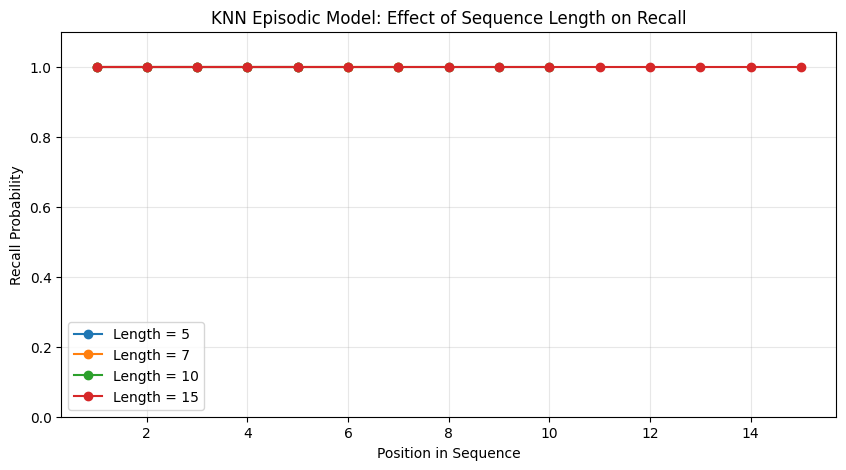

In [2]:
extended_vocab = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    'lemon': 'fruit', 'lime': 'fruit', 'apricot': 'fruit', 'fig': 'fruit', 'melon': 'fruit',
    'papaya': 'fruit', 'coconut': 'fruit'
}
ext_encoder = SymbolicEncoder(extended_vocab, embedding_dim=100, category_variance=0.2, seed=42)
ext_decoder = SymbolicDecoder(ext_encoder)
full_word_list = list(extended_vocab.keys())

seq_lengths = [5, 7, 10, 15]
n_trials = 30
results_mrr_len = {}
results_span_len = {}
results_fidelity_len = {}
curves_len = {}

for length in seq_lengths:
    print(f"Evaluating KNN sequence of length {length}...")
    current_words = full_word_list[:length]
    enc_words = ext_encoder.encode(current_words)
    context_seq = np.tile(np.array([1.0]), (len(current_words), 1))
    
    net = KNNEpisodicModel(n_features=100)
    net.fit_sequence(enc_words, context_data=context_seq)
    
    probs_theta = measure_recall_threshold(net, current_words, ext_encoder, ext_decoder, n_trials=n_trials)
    curves_len[length] = probs_theta
    results_mrr_len[length] = mean_recall_rate(probs_theta)
    results_span_len[length] = memory_span(probs_theta)
    results_fidelity_len[length] = recall_fidelity(net, current_words, ext_encoder, n_trials=n_trials)

print("\n--- Metric Summary Table: Sequence Length ---")
print("-" * 75)
print(f"{'Sequence Length':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print("-" * 75)
for length in seq_lengths:
    print(f"{length:<25} | {results_mrr_len[length]:<10.3f} | {results_span_len[length]:<15} | {results_fidelity_len[length]:<15.3f}")
print("-" * 75 + "\n")

plt.figure(figsize=(10, 5))
for length in seq_lengths:
    plt.plot(range(1, length+1), curves_len[length], marker='o', label=f'Length = {length}')
plt.title("KNN Episodic Model: Effect of Sequence Length on Recall")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. Multiple Sequences Benchmark (Catastrophic Forgetting)

This benchmark tests sequence retention under sequential training of distinct categories (Fruits, Animals, Cars). Unlike gradient-based models like GPT-2, a non-parametric KNN model does not overwrite past associations, and should retain perfect recall across all categories even when trained sequentially.

In [3]:
vocab_multi = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'dog': 'animal', 'cat': 'animal', 'horse': 'animal', 'cow': 'animal', 'sheep': 'animal',
    'ford': 'car', 'chevy': 'car', 'dodge': 'car', 'toyota': 'car', 'honda': 'car'
}
encoder_multi = SymbolicEncoder(vocab_multi, embedding_dim=100, category_variance=0.2, seed=42)
decoder_multi = SymbolicDecoder(encoder_multi)

lists = {
    'fruits': ['apple', 'banana', 'orange', 'grape', 'pear'],
    'animals': ['dog', 'cat', 'horse', 'cow', 'sheep'],
    'cars': ['ford', 'chevy', 'dodge', 'toyota', 'honda']
}
rng = np.random.default_rng(42)
context_map = {
    'fruits':  rng.integers(0, 2, size=32).astype(float),
    'animals': rng.integers(0, 2, size=32).astype(float),
    'cars':    rng.integers(0, 2, size=32).astype(float),
}

net_multi = KNNEpisodicModel(n_features=100)
stages_data = []

for idx, (cat, words) in enumerate(lists.items()):
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    
    print(f"Stage {idx+1}: Training KNN on {cat}...")
    net_multi.fit_sequences([(enc_words, context_seq)])
    
    stage_metrics = {}
    for c_cat in lists.keys():
        c_words = lists[c_cat]
        c_context = context_map[c_cat]
        
        curve_assoc = measure_recall_threshold(net_multi, c_words, encoder_multi, decoder_multi, c_context, n_trials=n_trials)
        curve_auto = measure_recall_autoregressive(net_multi, c_words, encoder_multi, decoder_multi, c_context, n_trials=n_trials)
        
        mrr = mean_recall_rate(curve_assoc)
        span = memory_span(curve_auto, threshold=0.75)
        fid = recall_fidelity(net_multi, c_words, encoder_multi, context_vec=c_context, n_trials=n_trials)
        
        stage_metrics[c_cat] = {'mrr': mrr, 'span': span, 'fidelity': fid}
    stages_data.append(stage_metrics)
    
    print("=" * 65)
    print(f"  Stage {idx+1} Primary Metrics (after training on: {cat})")
    print("-" * 65)
    print(f"  {'Category':<15} | {'MRR (Assoc)':<12} | {'Word Span':<12} | {'Recall Fidelity':<15}")
    print("-" * 65)
    for c_cat in lists.keys():
        metrics = stage_metrics[c_cat]
        print(f"  {c_cat:<15} | {metrics['mrr']:<12.3f} | {metrics['span']:<12} | {metrics['fidelity']:<15.3f}")
    print("=" * 65)
    print()


Stage 1: Training KNN on fruits...
  Stage 1 Primary Metrics (after training on: fruits)
-----------------------------------------------------------------
  Category        | MRR (Assoc)  | Word Span    | Recall Fidelity
-----------------------------------------------------------------
  fruits          | 1.000        | 4            | 1.000          
  animals         | 0.000        | 0            | -0.049         
  cars            | 0.000        | 0            | -0.056         

Stage 2: Training KNN on animals...
  Stage 2 Primary Metrics (after training on: animals)
-----------------------------------------------------------------
  Category        | MRR (Assoc)  | Word Span    | Recall Fidelity
-----------------------------------------------------------------
  fruits          | 1.000        | 4            | 1.000          
  animals         | 1.000        | 4            | 1.000          
  cars            | 0.000        | 0            | -0.054         

Stage 3: Training KNN on c